In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
from scipy import integrate
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors


def cmap_with_alpha_ramp(cmap, alpha_min=0.0, alpha_max=1.0, ramp_fraction=0.3):
    """
    ramp_fraction: fraction of the colormap (from bottom) over which alpha ramps up
    """
    colors = cmap(np.linspace(0, 1, cmap.N))
    alphas = np.ones(cmap.N)

    n_ramp = int(cmap.N * ramp_fraction)
    print('n_ramp:', n_ramp)  
    alphas[:n_ramp] = np.linspace(alpha_min, alpha_max, n_ramp)

    colors[:, -1] = alphas
    return mcolors.ListedColormap(colors)

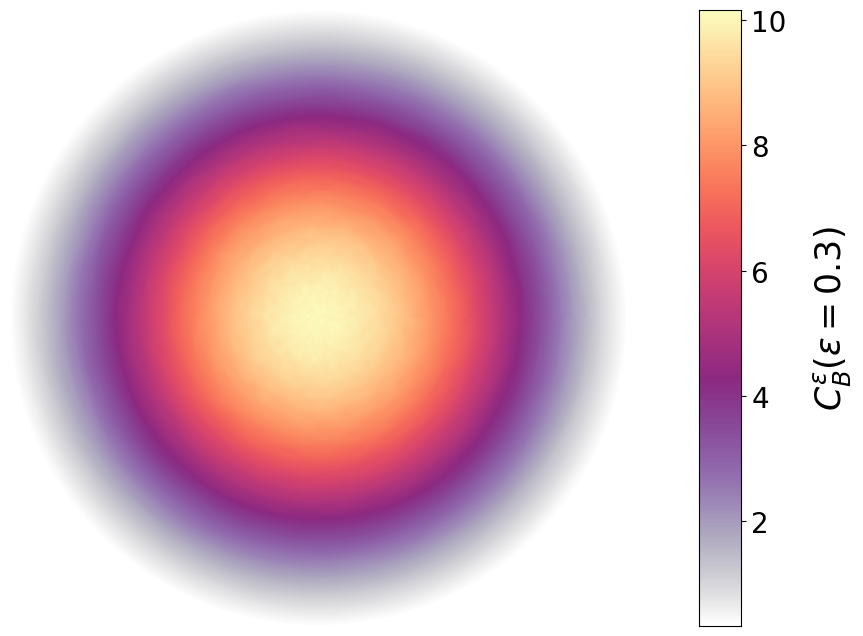

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -------------------- settings --------------------
eps = 0.3
gamma = 10
r_max = 1.0

Nr = 60
Nt = 50

imgN = 900            # raster resolution (increase for smoother)
ramp_fraction = 0.4   # bottom fraction of values fade in
alpha_min = 0.0
alpha_max = 1.0

# -------------------- load data --------------------
bwss = np.loadtxt(
    f'./bwss_continuum/bwss_polar_{int(eps*100)}_gam{gamma}.txt',
    delimiter=','
)
bwss = np.asarray(bwss)

# Ensure shape (Nr, Nt)
if bwss.shape == (Nt, Nr):
    bwss = bwss.T
if bwss.shape != (Nr, Nt):
    raise ValueError(f"bwss shape is {bwss.shape}, expected {(Nr, Nt)} or {(Nt, Nr)}")

bwss = np.ma.masked_invalid(bwss)

# -------------------- colormap + normalization --------------------
cmap = plt.colormaps["magma"]
vmin = float(np.nanmin(bwss))
vmax = float(np.nanmax(bwss))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# -------------------- build Cartesian raster from polar data --------------------
x = np.linspace(-r_max, r_max, imgN)
y = np.linspace(-r_max, r_max, imgN)
X, Y = np.meshgrid(x, y)

R = np.sqrt(X**2 + Y**2)
T = (np.arctan2(Y, X) + 2*np.pi) % (2*np.pi)

# map to index space
r_idx = (R / r_max) * (Nr - 1)
t_idx = (T / (2*np.pi)) * (Nt - 1)

r0 = np.floor(r_idx).astype(int)
t0 = np.floor(t_idx).astype(int)
r1 = np.clip(r0 + 1, 0, Nr - 1)
t1 = (t0 + 1) % Nt

r0 = np.clip(r0, 0, Nr - 1)
t0 = t0 % Nt

wr = r_idx - r0
wt = t_idx - t0

Z00 = bwss[r0, t0]
Z10 = bwss[r1, t0]
Z01 = bwss[r0, t1]
Z11 = bwss[r1, t1]

Z = (1-wr)*(1-wt)*Z00 + wr*(1-wt)*Z10 + (1-wr)*wt*Z01 + wr*wt*Z11

# mask outside disk (and propagate masked invalids)
Z = np.ma.array(Z, mask=(R > r_max) | np.ma.getmaskarray(Z))

# -------------------- apply color + alpha ramp (by value) --------------------
Zn = norm(Z)  # masked array in [0,1]

alpha = np.clip(Zn / ramp_fraction, 0, 1)
alpha = alpha_min + (alpha_max - alpha_min) * alpha
alpha = np.where(Z.mask, 0.0, alpha)  # outside disk transparent

rgba = cmap(Zn.filled(0.0))
rgba[..., 3] = alpha

# -------------------- plot main image + alpha-aware colorbar --------------------
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[1, 0.06], wspace=0.08)

ax = fig.add_subplot(gs[0, 0])
ax.set_axis_off()
ax.set_aspect("equal")

ax.imshow(
    rgba,
    origin="lower",
    extent=[-r_max, r_max, -r_max, r_max],
    interpolation="bilinear"
)

# --- alpha-aware colorbar drawn as an RGBA image ---
cax = fig.add_subplot(gs[0, 1])

cb_N = 256
vals = np.linspace(vmin, vmax, cb_N)
vals_n = norm(vals)

alpha_cb = np.clip(vals_n / ramp_fraction, 0, 1)
alpha_cb = alpha_min + (alpha_max - alpha_min) * alpha_cb

rgba_cb = cmap(vals_n)
rgba_cb[:, 3] = alpha_cb

cax.imshow(
    rgba_cb[:, None, :],
    aspect="auto",
    origin="lower",
    extent=[0, 1, vmin, vmax],
    interpolation="nearest"
)

cax.set_xticks([])
cax.yaxis.tick_right()
cax.tick_params(axis="y", labelsize=20)

cax.set_ylabel(rf"$C_B^\varepsilon(\epsilon = {eps})$", fontsize=25, rotation=90, labelpad=18)
cax.yaxis.set_label_position("right")
plt.savefig('./figs/cont_bwss_tol30.png', dpi=300)
plt.show()


In [ ]:
#%% ---------------------------- PLOT ERROR -----------------------------------
import numpy as np
import matplotlib.pyplot as plt

# Load the bwss and errs data
bwss = np.loadtxt('./bwss_continuum/bwss_polar_0.txt', delimiter=',')
errs = np.loadtxt('./bwss_continuum/err_bwss_polar_0.txt', delimiter=',')
# Plot the error
fig_err = plt.figure(figsize=(13, 8))
ax_err = plt.subplot(111, projection='polar')

# Ensure r and theta are 1D arrays
r = np.linspace(0, 1, 61)          # 61 edges → 60 cells
theta = np.linspace(0, 2*np.pi, 51) # 51 edges → 50 cells

pcm_err = ax_err.pcolormesh(theta, r, errs, cmap='viridis', shading='auto')  # shading='auto' adjusts automatically
plt.colorbar(pcm_err)
plt.show()

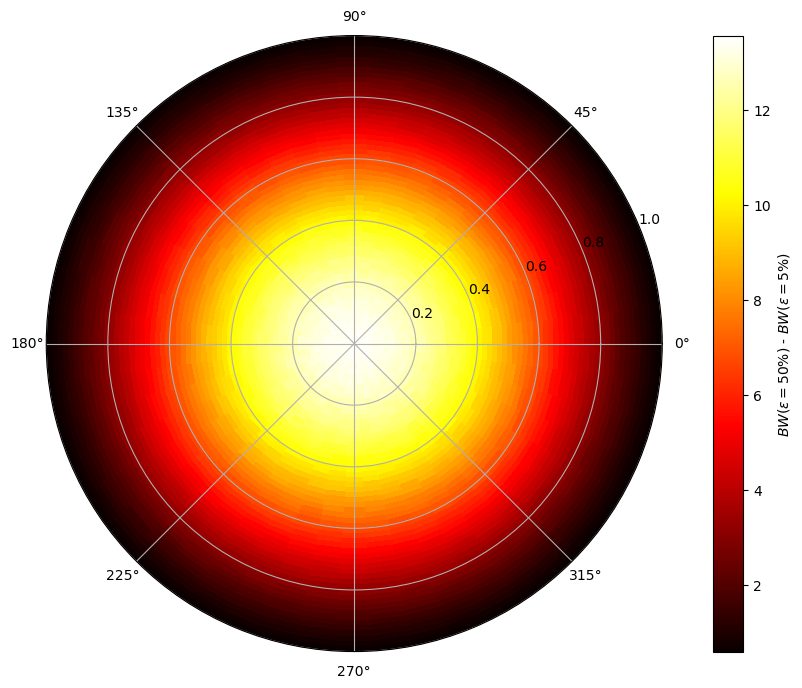

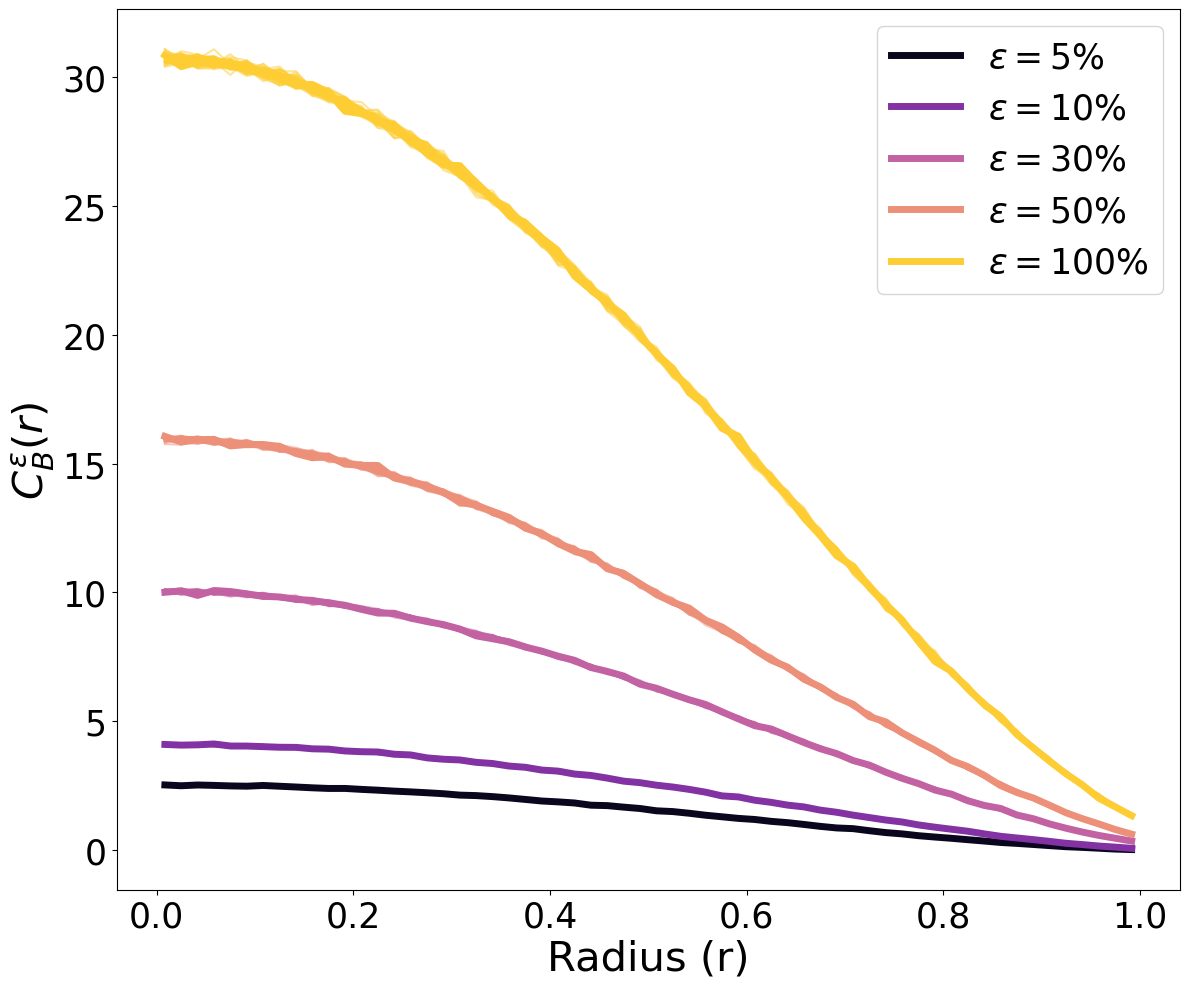

In [11]:
#%% ---------------------------- PLOT DIFFERENCE -----------------------------------
import numpy as np
import matplotlib.pyplot as plt
gamma = 10
tols = [5, 10, 30, 50, 100]
all_bwss = []
for i, tol in enumerate(tols):
    bwss = np.loadtxt(f'./bwss_continuum/bwss_polar_{tol}_gam{gamma}.txt', delimiter=',')
    all_bwss.append(bwss)
# Plot the error
fig_err = plt.figure(figsize=(13, 8))
ax_err = plt.subplot(111, projection='polar')

# Ensure r and theta are 1D arrays
r = np.linspace(0, 1, 61)          # 61 edges → 60 cells
theta = np.linspace(0, 2*np.pi, 51) # 51 edges → 50 cells

pcm_err = ax_err.pcolormesh(theta, r, all_bwss[3]-all_bwss[0], cmap='hot', shading='auto')  # shading='auto' adjusts automatically
plt.colorbar(pcm_err, label=r'$BW(\epsilon = '+str(tols[3])+'\%)$ - $BW(\epsilon = '+str(tols[0])+'\%)$')
plt.show()
# ----------------------------

# PLOT THE BWSS FOR EACH THETA
def fun(x, a, b, c):
    return a * np.exp(-b*x**c)

from scipy.optimize import curve_fit

r_centers = 0.5 * (r[:-1] + r[1:])
theta_centers = 0.5 * (theta[:-1] + theta[1:])
# Get the Viridis colormap
cmap = plt.get_cmap("inferno")

# Generate N evenly spaced colors from the colormap
colors = cmap(np.linspace(0, 0.8, len(tols)))  # Adjust 5 to however many lines you have
colors[:, :3] = colors[:, :3]** 0.5

fig, ax = plt.subplots(figsize=(12, 10))
for tol_i, tol in enumerate(tols):
    for i, th_v in enumerate(theta_centers):
        if i == 0:  # only add labels once
            # ax.plot(r_centers, all_bwss[tol_i][:, i], alpha=0.5, c='k')
            ax.plot(r_centers, all_bwss[tol_i][:, i], lw = 5 , label=r'$\epsilon = $' + str(tol)+'%', c=colors[tol_i])

        else:
            # ax.plot(r_centers, all_bwss[tol_i][:, i], alpha=0.5, c='k')
            ax.plot(r_centers, all_bwss[tol_i][:, i], alpha=0.5, c=colors[tol_i])

# ax.plot(r_centers, fun(r_centers, *popt), label=f'Fit', alpha=0.5)
ax.set_xlabel('Radius (r)', fontsize=30)
ax.set_ylabel(r'$C_B^\varepsilon (r)$', fontsize=30)
ax.tick_params('both',labelsize=25)
# ax.set_yscale('log')
ax.legend(fontsize=25)
plt.tight_layout()
plt.savefig('./figs/bwss_r_gamma10.png')

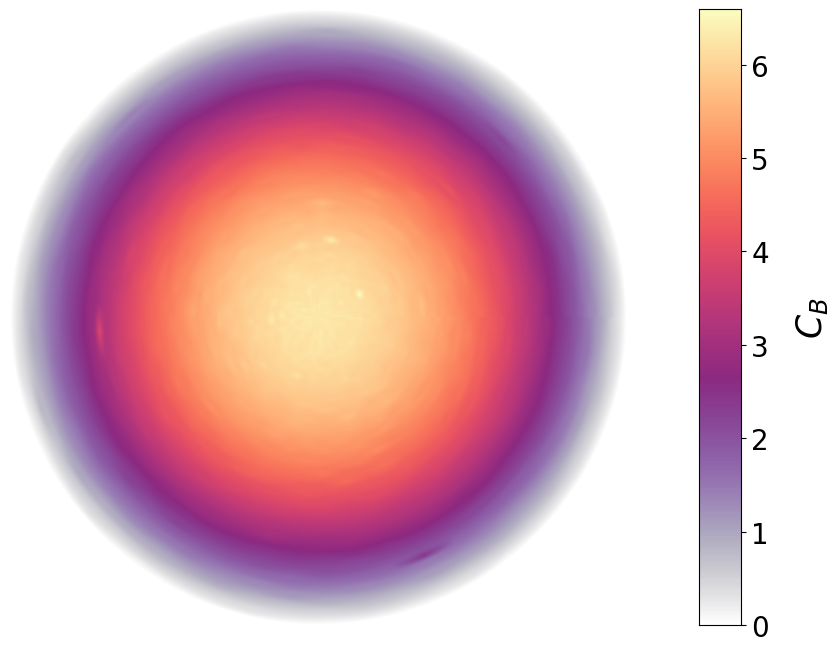

In [11]:
# PLOT THE SHORTEST PATH BETWEENNESS

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -------------------- settings --------------------
eps = 0
r_max = 1.0

Nr = 60
Nt = 50

imgN = 900            # raster resolution (increase for smoother)
ramp_fraction = 0.4   # bottom fraction of values fade in
alpha_min = 0.0
alpha_max = 1.0

# -------------------- load data --------------------
bwss = np.loadtxt(
    f'./bwss_continuum/bwss_polar_{int(eps*100)}.txt',
    delimiter=','
)
bwss = np.asarray(bwss)

# Ensure shape (Nr, Nt)
if bwss.shape == (Nt, Nr):
    bwss = bwss.T
if bwss.shape != (Nr, Nt):
    raise ValueError(f"bwss shape is {bwss.shape}, expected {(Nr, Nt)} or {(Nt, Nr)}")

bwss = np.ma.masked_invalid(bwss)

# -------------------- colormap + normalization --------------------
cmap = plt.colormaps["magma"]
vmin = float(np.nanmin(bwss))
vmax = float(np.nanmax(bwss))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# -------------------- build Cartesian raster from polar data --------------------
x = np.linspace(-r_max, r_max, imgN)
y = np.linspace(-r_max, r_max, imgN)
X, Y = np.meshgrid(x, y)

R = np.sqrt(X**2 + Y**2)
T = (np.arctan2(Y, X) + 2*np.pi) % (2*np.pi)

# map to index space
r_idx = (R / r_max) * (Nr - 1)
t_idx = (T / (2*np.pi)) * (Nt - 1)

r0 = np.floor(r_idx).astype(int)
t0 = np.floor(t_idx).astype(int)
r1 = np.clip(r0 + 1, 0, Nr - 1)
t1 = (t0 + 1) % Nt

r0 = np.clip(r0, 0, Nr - 1)
t0 = t0 % Nt

wr = r_idx - r0
wt = t_idx - t0

Z00 = bwss[r0, t0]
Z10 = bwss[r1, t0]
Z01 = bwss[r0, t1]
Z11 = bwss[r1, t1]

Z = (1-wr)*(1-wt)*Z00 + wr*(1-wt)*Z10 + (1-wr)*wt*Z01 + wr*wt*Z11

# mask outside disk (and propagate masked invalids)
Z = np.ma.array(Z, mask=(R > r_max) | np.ma.getmaskarray(Z))

# -------------------- apply color + alpha ramp (by value) --------------------
Zn = norm(Z)  # masked array in [0,1]

alpha = np.clip(Zn / ramp_fraction, 0, 1)
alpha = alpha_min + (alpha_max - alpha_min) * alpha
alpha = np.where(Z.mask, 0.0, alpha)  # outside disk transparent

rgba = cmap(Zn.filled(0.0))
rgba[..., 3] = alpha

# -------------------- plot main image + alpha-aware colorbar --------------------
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[1, 0.06], wspace=0.08)

ax = fig.add_subplot(gs[0, 0])
ax.set_axis_off()
ax.set_aspect("equal")

ax.imshow(
    rgba,
    origin="lower",
    extent=[-r_max, r_max, -r_max, r_max],
    interpolation="bilinear"
)

# --- alpha-aware colorbar drawn as an RGBA image ---
cax = fig.add_subplot(gs[0, 1])

cb_N = 256
vals = np.linspace(vmin, vmax, cb_N)
vals_n = norm(vals)

alpha_cb = np.clip(vals_n / ramp_fraction, 0, 1)
alpha_cb = alpha_min + (alpha_max - alpha_min) * alpha_cb

rgba_cb = cmap(vals_n)
rgba_cb[:, 3] = alpha_cb

cax.imshow(
    rgba_cb[:, None, :],
    aspect="auto",
    origin="lower",
    extent=[0, 1, vmin, vmax],
    interpolation="nearest"
)

cax.set_xticks([])
cax.yaxis.tick_right()
cax.tick_params(axis="y", labelsize=20)

cax.set_ylabel(rf"$C_B$", fontsize=25, rotation=90, labelpad=18)
cax.yaxis.set_label_position("right")
plt.savefig('./figs/sp_bwss_cont.png', dpi=300)
plt.show()

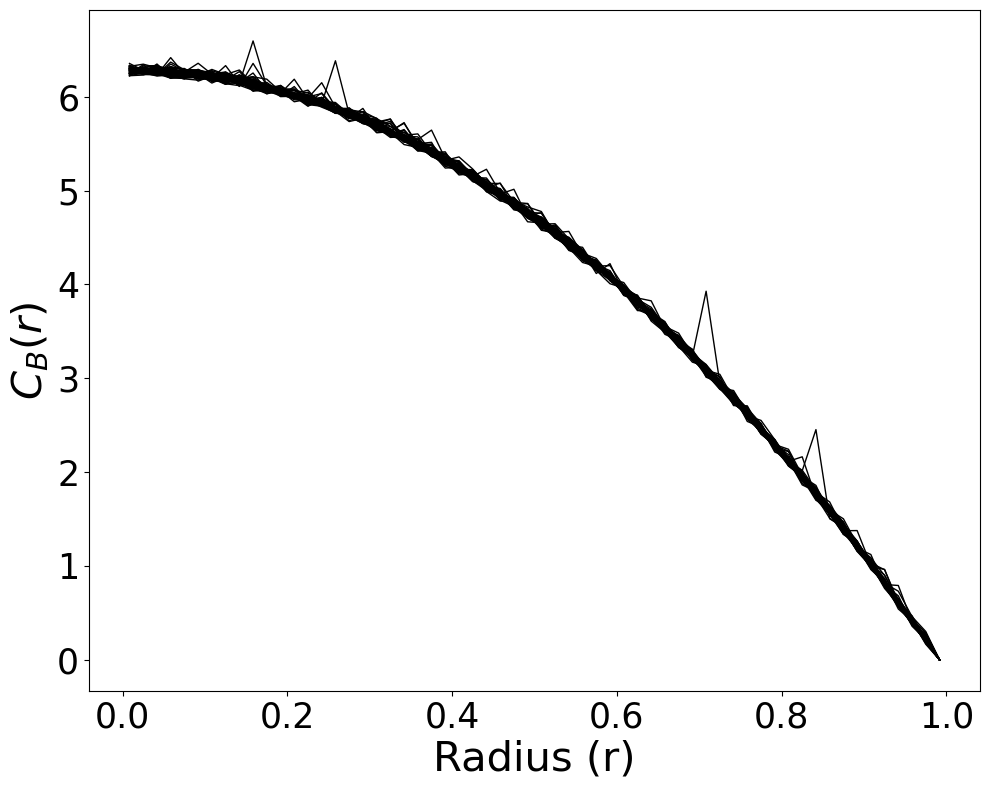

In [15]:
# PLOT THE BWSS FOR EACH THETA
def fun(x, a, b, c):
    return a * np.exp(-b*x**c)

from scipy.optimize import curve_fit
r = np.linspace(0, 1, 61)          # 61 edges → 60 cells
theta = np.linspace(0, 2*np.pi, 51) # 51 edges → 50 cells

r_centers = 0.5 * (r[:-1] + r[1:])
theta_centers = 0.5 * (theta[:-1] + theta[1:])
# Get the Viridis colormap
cmap = plt.get_cmap("inferno")

# Generate N evenly spaced colors from the colormap
colors = cmap(np.linspace(0, 0.8, 5))  # Adjust 5 to however many lines you have
colors[:, :3] = colors[:, :3]** 0.5

fig, ax = plt.subplots(figsize=(10, 8))
for i, th_v in enumerate(theta_centers):
    if i == 0:  # only add labels once
        # ax.plot(r_centers, all_bwss[tol_i][:, i], alpha=0.5, c='k')
        ax.plot(r_centers, bwss[:, i], lw = 1 , c='k')

    else:
        # ax.plot(r_centers, all_bwss[tol_i][:, i], alpha=0.5, c='k')
        ax.plot(r_centers,bwss[:, i], lw = 1 , c='k')
# ax.plot(r_centers, fun(r_centers, *popt), label=f'Fit', alpha=0.5)
ax.set_xlabel('Radius (r)', fontsize=30)
ax.set_ylabel(r'$C_B(r)$', fontsize=30)
ax.tick_params('both',labelsize=25)

plt.tight_layout()
# plt.savefig('./figs/sp_bwss_cont_r.png')